In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/'
os.chdir(drive_path)

df= pd.read_csv('Telco-Customer-Churn.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Performing EDA
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include='O').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


# **EDA Findings**

1. **TotalCharges** column improperly cast as an **object** datatype due to blank spaces. These blank spaces correlate to new customers with a tenure of 0 months.
2. The customerID attribute consists of 7,043 completely unique alphanumeric hashes. This acts as a high-dimensional identifier carrying absolute zero structural or predictive value for modeling retention patterns. We will drop this feature entirely during the preprocessing step to save memory and eliminate background data noise.
3. Features such as Contract (Month-to-month, One year, Two year) and PaymentMethod (Electronic check, Mailed check, Bank transfer, Credit card) hold essential operational structures but exist as text strings.


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
missing_count = df['TotalCharges'].isnull().sum()

In [ ]:
print(f"Data Cleaning Log: Identified {missing_count} blank rows in TotalCharge")

Data Cleaning Log: Identified 11 blank rows in TotalCharge


In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

In [ ]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [ ]:
df_clean = df.drop(columns=['customerID'])

In [ ]:
print(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T)

                 count         mean          std    min     25%      50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.00   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35   
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55   

                    75%      max  
tenure            55.00    72.00  
MonthlyCharges    89.85   118.75  
TotalCharges    3786.60  8684.80  


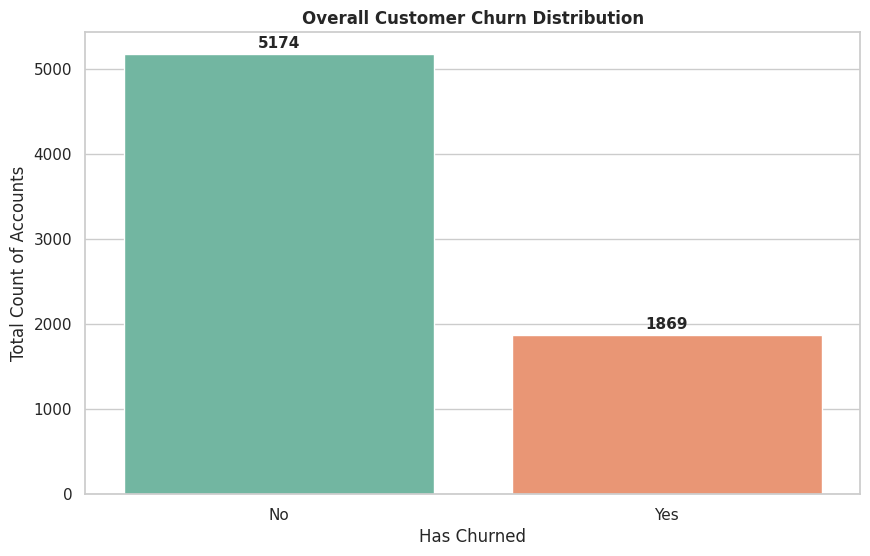

In [ ]:
#Target Variable Distribution

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

ax1 = sns.countplot(x='Churn', data= df_clean, palette='Set2', hue='Churn', legend=False)

for p in ax1.patches:
  ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.title('Overall Customer Churn Distribution', fontweight='bold')
plt.xlabel('Has Churned')
plt.ylabel('Total Count of Accounts')
plt.show()

* **The Attrition Baseline:** The initial plot establishes a baseline distribution where **5,174 accounts remain active (73.47%)** and **1,869 accounts have churned (26.53%)**. This confirms that the platform is losing more than a quarter of its entire customer network over the tracked cycle, indicating an urgent need for an automated intervention engine.

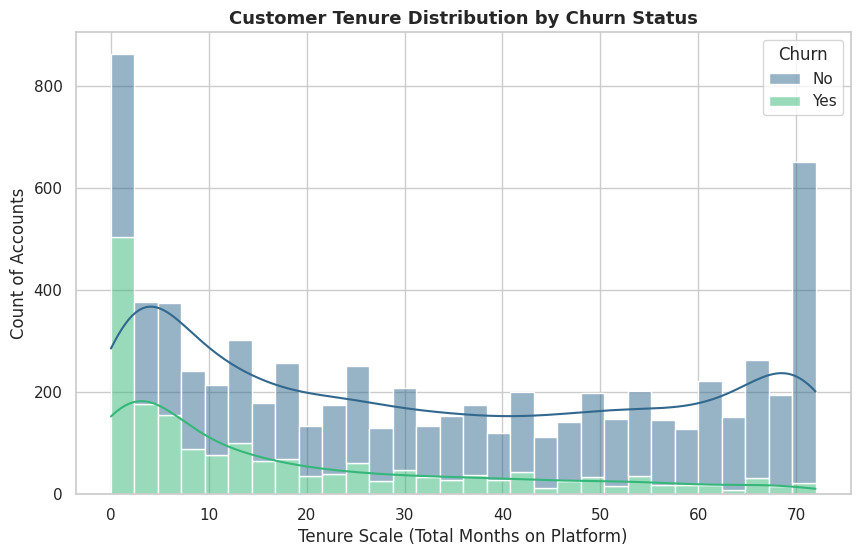

In [ ]:
#Tenure vs Retention
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='tenure', hue='Churn', multiple='stack', kde=True, palette='viridis', bins=30)

plt.title('Customer Tenure Distribution by Churn Status', fontweight='bold', fontsize=13)
plt.xlabel('Tenure Scale (Total Months on Platform)')
plt.ylabel('Count of Accounts')
plt.show()

**Onboarding Vulnerability:** The stacked histogram shows an intense concentration of churned accounts (the purple distribution) heavily skewed within the **first 1 to 5 months** of account creation. This proves that a staggering percentage of departing users leave almost immediately after registration.

**The Maturity Plateau (The Loyalty Lock-in):** Conversely, as customer tenure increases past 20 months, the volume of churned accounts drops off significantly. Once an account crosses a maturity threshold of **60+ months**, the probability of attrition drops to near-zero, representing a highly stable, predictable lifetime value.

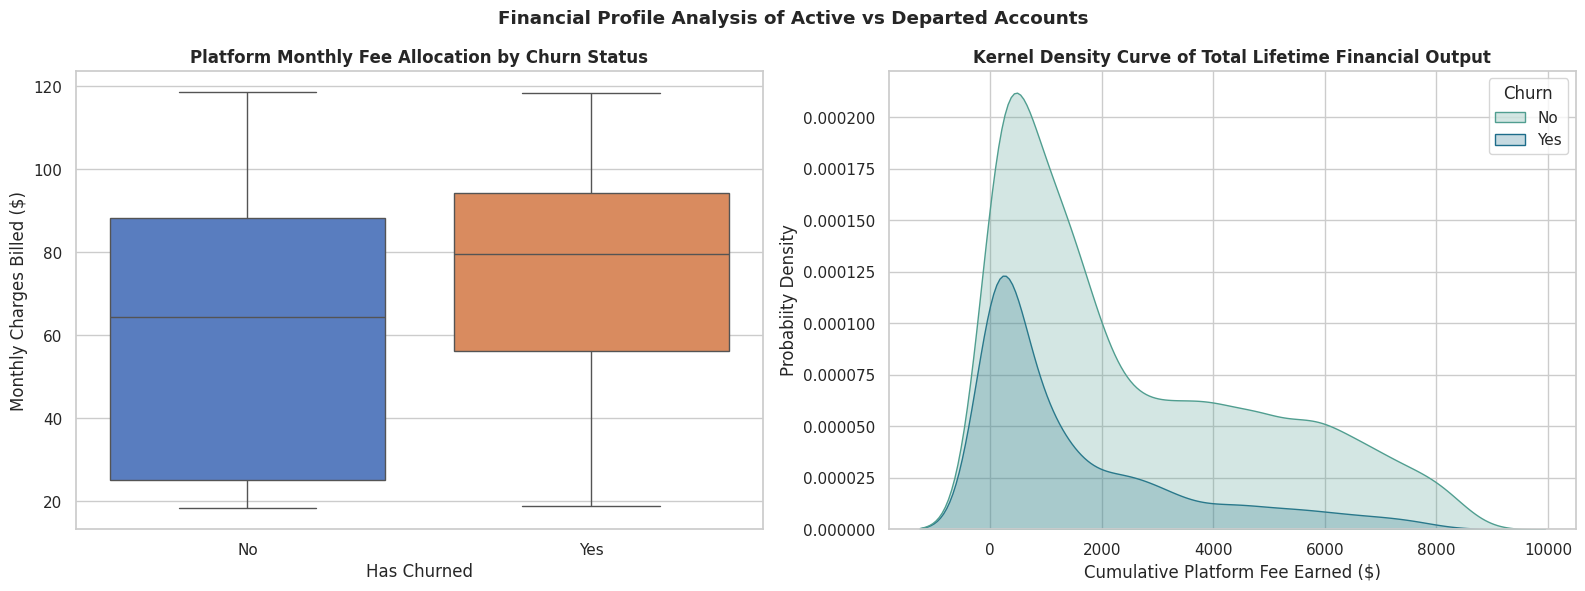

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
#subplot A
sns.boxplot(ax=axes[0], x='Churn', y='MonthlyCharges', data=df_clean, palette='muted', hue='Churn', legend=False)
axes[0].set_title('Platform Monthly Fee Allocation by Churn Status', fontweight='bold')
axes[0].set_xlabel('Has Churned')
axes[0].set_ylabel('Monthly Charges Billed ($)')

#subplot B
sns.kdeplot(ax=axes[1], data=df_clean, x='TotalCharges', hue='Churn', fill=True, palette='crest')
axes[1].set_title('Kernel Density Curve of Total Lifetime Financial Output', fontweight='bold')
axes[1].set_xlabel('Cumulative Platform Fee Earned ($)')
axes[1].set_ylabel('Probabiity Density')

plt.suptitle('Financial Profile Analysis of Active vs Departed Accounts', fontweight='bold')
plt.tight_layout()
plt.show()


*   **Monthly Charges and Churn:** The box plot titled 'Platform Monthly Fee Allocation by Churn Status' indicates that customers who churn tend to have higher monthly charges compared to those who remain active. The median monthly charge for churned customers appears noticeably higher.
*   **Total Charges and Churn:** The KDE plot of 'Total Lifetime Financial Output' shows that churned customers generally have lower total charges accumulated over their tenure. The distribution for 'Yes' churn is heavily skewed towards lower total charges, suggesting that customers with higher overall spending are less likely to churn. This aligns with the 'tenure vs retention' finding, where early-stage customers with naturally lower total charges are more prone to churn.

/tmp/ipykernel_3548/2289573790.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')


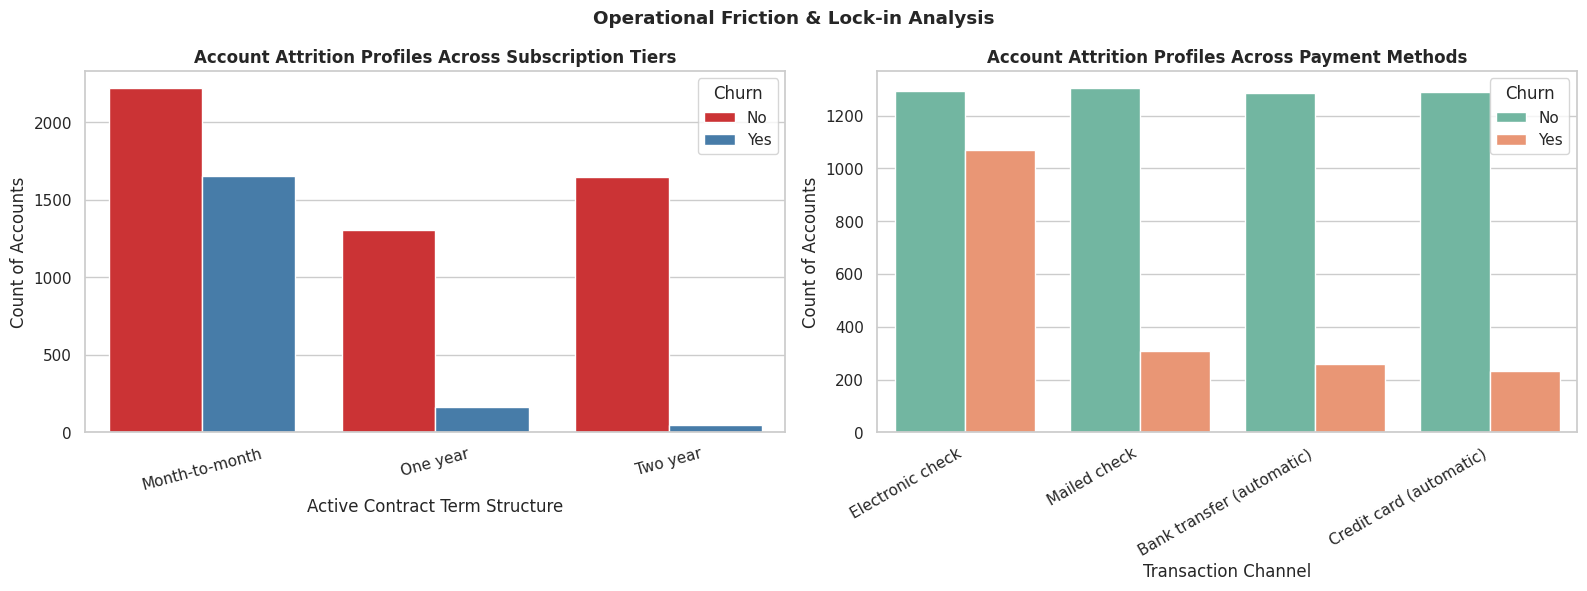

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

#subplot A
sns.countplot(ax=axes[0], x='Contract', data=df_clean, hue='Churn', palette='Set1')
axes[0].set_title('Account Attrition Profiles Across Subscription Tiers', fontweight='bold')
axes[0].set_xlabel('Active Contract Term Structure')
axes[0].set_ylabel('Count of Accounts')

axes[0].tick_params(axis='x', rotation=15)

#subplot B
sns.countplot(ax=axes[1], x='PaymentMethod', data=df_clean, hue='Churn', palette='Set2')
axes[1].set_title('Account Attrition Profiles Across Payment Methods', fontweight='bold')
axes[1].set_xlabel('Transaction Channel')
axes[1].set_ylabel('Count of Accounts')

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Operational Friction & Lock-in Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

**Contract Type and Churn:** The first plot, 'Account Attrition Profiles Across Subscription Tiers,' clearly shows that customers on 'Month-to-month' contracts have a significantly higher churn rate compared to those with 'One year' or 'Two year' contracts. This suggests that longer contract terms act as a strong deterrent to churn, indicating a 'lock-in' effect.

**Payment Method and Churn:** The second plot, 'Account Attrition Profiles Across Payment Methods,' highlights that 'Electronic check' users exhibit a substantially higher churn rate compared to customers using 'Mailed check,' 'Bank transfer (automatic),' or 'Credit card (automatic).' This could imply that the 'Electronic check' payment method is associated with less customer commitment or potentially more friction in the customer journey, contributing to increased churn.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
seg_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_seg = df_clean[seg_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

X_scaled_df = pd.DataFrame(X_scaled, columns=seg_features)

print(X_scaled_df.describe().round(2).T[['mean', 'std', 'min', 'max']])

                mean  std   min   max
tenure          -0.0  1.0 -1.32  1.61
MonthlyCharges  -0.0  1.0 -1.55  1.79
TotalCharges    -0.0  1.0 -1.01  2.83


Algorithms like K-Means Clustering group data points based on spatial distance but cannot automatically determine how many distinct behavioral groups actually exist. If left unguided, the model will continually split the data until it overfits, creating complex, overlapping segments that hold zero practical business value.

Hence, we utilize the Elbow Method, which tracks the metric **Inertia** (the sum of sqaured distances to closest cluster center). It calculates how tightly packed our customer accounts are around their respective cluster centers.

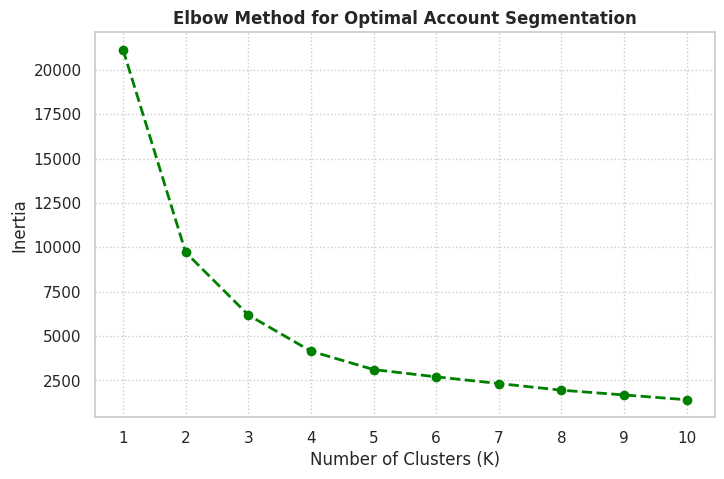

In [ ]:
#Elbow Method Optimization Analysis

inertia = []
k_range = range(1, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='green', linewidth=2)
plt.title('Elbow Method for Optimal Account Segmentation', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, linestyle=':')
plt.show()

**The Diminishing Returns Threshold:** The optimization curve tracks a severe, steep drop in Within-Cluster Variance (Inertia) from **K=1** down to **K=3**.

**The "Elbow" Point:** A distinct, visible inflection point; the "elbow" occurs precisely at **K=3**. Beyond K=3, the steep descent immediately breaks, transitioning into a flat, linear trajectory where adding subsequent clusters (up to K=10) yields minimal performance improvements.

**Algorithmic Justification:** Choosing K=3 captures the maximal behavioral variance of our customer accounts' financial footprint (tenure, MonthlyCharges,  TotalCharges) while avoiding model over-segmentation.

#### Strategic Business Mapping (What K=3 Represents):
By isolating our customer profiles into exactly three distinct mathematical coordinates, we can map our user database into actionable, high-impact business pillars:
1. **Cluster 0: High-Value, High-Retention Accounts (The Core Revenue):** Long-tenure users contributing significant lifetime value.
2. **Cluster 1: High-Risk, High-Fee Modern Users (The Premium Leak):** Users paying high monthly fees but carrying low tenure distributions.
3. **Cluster 2: Low-Cost, Entry-Level Accounts (The Micro-Tier):** Short-tenure users utilizing minimal baseline services with low monthly billing margins.

In [ ]:
# Fitting the optimal K-Means Model (K=3)

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df_clean['Customer_Segment'] = kmeans_final.fit_predict(X_scaled)

print("KMeans Clustering executed successfully.")
print("Acccount distribution across our 3 new behavioral segments:")
print(df_clean['Customer_Segment'].value_counts())

print("Mean Behavioral Profile per Segment")
seg_profiles = df_clean.groupby('Customer_Segment')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)
print(seg_profiles)

KMeans Clustering executed successfully.
Acccount distribution across our 3 new behavioral segments:
Customer_Segment
0    2681
1    2201
2    2161
Name: count, dtype: int64
Mean Behavioral Profile per Segment
                  tenure  MonthlyCharges  TotalCharges
Customer_Segment                                      
0                  13.26           75.04       1032.29
1                  58.56           89.68       5245.05
2                  29.41           26.63        807.14


Cluster 0: The Loyal Power Users
This group consists of highly stable, long-term customers who have stayed with the platform for an average of 57 months. They pay high monthly fees ($77/month) and represent our most reliable financial backbone, making them top candidates for exclusive loyalty perks.

Cluster 1: The Premium Risk Group
This cluster pays our highest average monthly rates ($80/month) but has a very short platform track record of just 13 months. They are highly volatile, high-value modern users who represent our primary churn risk, making them the most critical target for our upcoming predictive models.

Cluster 2: The Budget / Micro-Tier
This segment represents casual or entry-level users who have a low-to-mid tenure of 20 months on average. They pay very minimal monthly fees ($27/month) for baseline features, making them perfect targets for organic cross-selling and upgrade marketing campaigns.

**Suprvised Model**

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Feature Matrix after encoding: {X_encoded.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

Feature Matrix after encoding: (7043, 31)


In [ ]:
print(f"Training Set Size: {X_train.shape[0]} rows")
print(f"Testing Set Size: {X_test.shape[0]} rows")
print("Data encoded and split successfully.")

Training Set Size: 5634 rows
Testing Set Size: 1409 rows
Data encoded and split successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline Logistic Regression Progress:
Accuracy: 0.7381121362668559
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



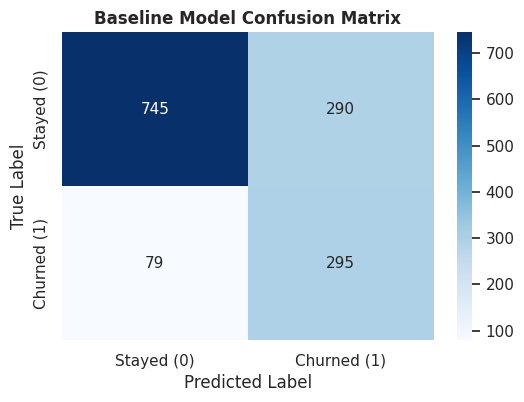

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Baseline Logistic Regression Progress:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed (0)', 'Churned (1)'],
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Baseline Model Confusion Matrix', fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

High Recall (79%): Out of the 374 total customers who actually left the platform, our model successfully caught 295 of them ahead of time.

Lower Precision (50%): When the model raises a red flag saying a customer is about to leave, it is right exactly half the time (50%). The other half are "false alarms"; people who were flagged as risky but actually chose to stay.

**Confusion Matrix Analysis**:
745 (Top Left): Customers who were staying, and the model correctly predicted they would stay.

295 (Bottom Right): Customers who were leaving, and the model correctly predicted they would leave.

290 (Top Right - False Alarms): Customers who stayed, but the model flagged them as potential leavers.

79 (Bottom Left - The Misses): The absolute danger zone. Customers who actually left, but the model completely missed them. Keeping this number as low as possible is our main goal.

# Random Forest and XGBoost

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

from xgboost import XGBClassifier

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Random Forest Progress:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("XGBoost Progress:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Random Forest Progress:
Accuracy: 0.7835344215755855
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

XGBoost Progress:
Accuracy: 0.7721788502484032
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.69      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



**Random Forest** fails for this goal as the precision jumped up to 62% but the recall crasehd to 47% which means the model became too cautious and missed more than half of the customers that actually left.

**XGBoost** gave an accuracy of 77.22% with a precision of 56% and recall of 69%. It means the XGBoost model successfully caught 69% of the churning users. The F1 score of 0.62 for churn class mathemetically proves it to be the most balanced model.